In [1]:
import pandas as pd

df = pd.DataFrame({"a":[1,2,3], "b":[-10,3,30]})

In [2]:
from sklearn.preprocessing import StandardScaler

#Standarization
scale = StandardScaler()
dfs = scale.fit_transform(df)
print(dfs)

[[-1.22474487 -1.06042425]
 [ 0.         -0.28011207]
 [ 1.22474487  1.34053632]]


In [3]:
from sklearn.preprocessing import MinMaxScaler

#Normalization min-max
min_max_scaler = MinMaxScaler()
dfn = min_max_scaler.fit_transform(df)
print(dfn)

[[0.    0.   ]
 [0.5   0.325]
 [1.    1.   ]]


Find minimum value of $f(x,y) = 2x+y$ where $x+y^2 \leq 1$ and $x \geq 0.2$

In [1]:
from scipy.optimize import minimize

cons = ({'type': 'ineq', 'fun': lambda w:  w[0]-0.2},
        {'type': 'ineq', 'fun': lambda w: 1-w[0]-w[1]**2})

fun = lambda w: 2*w[0]+w[1]
res = minimize(fun, (1,1), method='SLSQP',constraints=cons)
print(res.x) 

[ 0.2        -0.89442724]


In [2]:
#from the lecture

from scipy.optimize import minimize

cons = ({'type': 'ineq', 'fun': lambda w:  w[0]+w[1]-1},
        {'type': 'ineq', 'fun': lambda w: 5-w[0]**2-w[1]**2})

fun = lambda w: w[0]**2 - w[1]**2
res = minimize(fun, (1,1), method='SLSQP',constraints=cons)
print(res.x) 

[-4.52299121e-09  2.23606798e+00]


In [3]:
cons = ({'type': 'ineq', 'fun': lambda w:  6-w[0]-w[1]},
        {'type': 'ineq', 'fun': lambda w: 10-w[0]-w[1]},
        {'type': 'ineq', 'fun': lambda w: 11-4*w[0]-w[1]},
        {'type': 'ineq', 'fun': lambda w: 5*w[0]+w[1]-2},
        {'type': 'ineq', 'fun': lambda w: 7*w[0]+w[1]-6},
        {'type': 'ineq', 'fun': lambda w: 10*w[0]+w[1]-4})

from scipy.optimize import minimize

fun = lambda w: min(abs((1)*w[0]+(6)*(-1)+w[1])/(w[0]**2+1)**0.5,
                    abs((1)*w[0]+(10)*(-1)+w[1])/(w[0]**2+1)**0.5,
                    abs((4)*w[0]+(11)*(-1)+w[1])/(w[0]**2+1)**0.5,
                    abs((5)*w[0]+(2)*(-1)+w[1])/(w[0]**2+1)**0.5,
                    abs((7)*w[0]+(6)*(-1)+w[1])/(w[0]**2+1)**0.5,
                    abs((10)*w[0]+(4)*(-1)+w[1])/(w[0]**2+1)**0.5
                   )

fun2 = lambda w: -fun(w)
res = minimize(fun2, (1,1), method='SLSQP',constraints=cons)
print(res.x) #where is the minimum?

[ 1.66666637 -0.66665672]


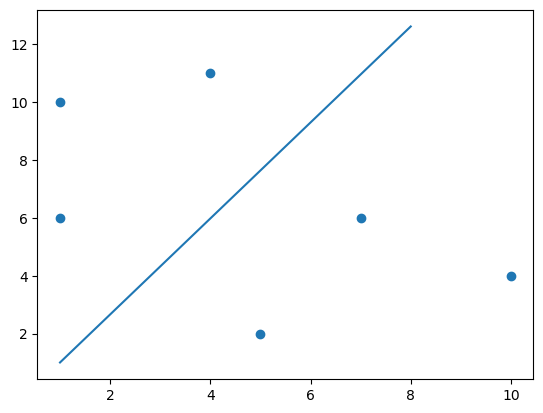

In [6]:
import matplotlib.pyplot as plt
import numpy as np

x = [1,1,4,5,7,10]
y = [6,10,11,2,6,4]
x1 = np.linspace(1, 8, 100)
y1 = 1.66*x1 - 0.66
plt.scatter(x,y)
plt.plot(x1,y1)
plt.show()

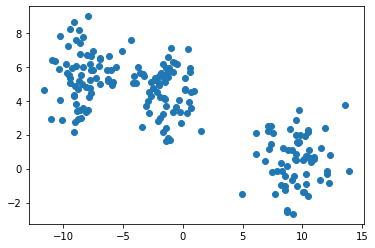

In [42]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt
import numpy as np


X, y = make_blobs(n_samples=200, random_state=7,
                  n_features=2, centers = 3, 
                  cluster_std = 1.5) 

plt.scatter(X[:, 0], X[:, 1])
plt.show()  

In [43]:
def kmeans(X, n =3, max_iter = 4):
    size = len(X)
    t = np.random.randint(0, size, n)
    c  = [X[t[i]] for i in range(n)]
    y = [0]*size
    for i in range(max_iter):
        for j in range(size):
            d = np.array([np.linalg.norm(c[k] - X[j]) for k in range(n)])
            where_min = np.argmin(d)
            y[j] = where_min          
        for j in range(n):
            c[j] = np.mean(np.array([X[k] for k in range(size) if y[k] == j]), axis = 0)
    return y


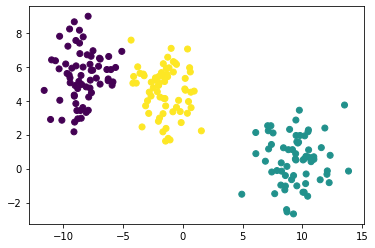

In [35]:
plt.scatter(X[:,0], X[:,1], c = kmeans(X))
plt.show()

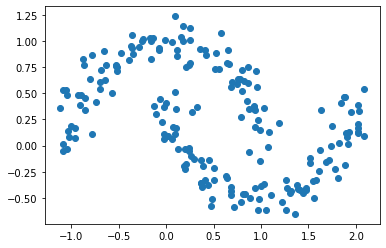

In [36]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=200, noise=.1,
                  random_state=41)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

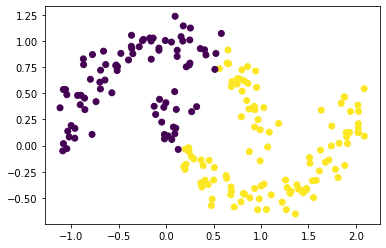

In [15]:
plt.scatter(X[:,0], X[:,1], c = kmeans(X, n=2))
plt.show()